In [21]:
# To be able to make edits to repo without having to restart notebook
%load_ext autoreload
%autoreload 2
import sys, os
sys.path.append(os.path.dirname(os.getcwd()))

import json
import pathlib
import pandas as pd
import mongomock
import xarray as xr
import cv2
from scipy import signal
import numpy as np
from fsspec.implementations.local import LocalFileSystem
from pathlib import Path
import matplotlib.pyplot as plt
from signalstore import UnitOfWorkProvider
from pymongo import MongoClient
import shutil
# Functions

def deserialize_dataarray(data_object):
        """Deserializes a data object.
        Arguments:
            data_object {dict} -- The data object to deserialize.
        Returns:
            dict -- The deserialized data object.
        """
        attrs = data_object.attrs.copy()
        for key, value in attrs.items():
            if isinstance(value, str):
                value = value.replace("'", '"')
                if value.lower() == 'true':
                    attrs[key] = True
                elif value.lower() == 'false':
                    attrs[key] = False
                elif value.lower() == 'none':
                    attrs[key] = None
                elif value.startswith('{'):
                    attrs[key] = json.loads(value)
            if isinstance(value, np.ndarray):
                attrs[key] = value.tolist()
        data_object.attrs = attrs
        return data_object



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
# Mock DB client
mongo_uri = os.environ.get("MONGO_URI", "mongodb://localhost:27017")
mongo_client = MongoClient(mongo_uri)
# -------------------------------------------------------------------

# 1) Define your container‐side data root (where "input" and "internal" are siblings)
# DATA_ROOT     = Path.cwd().parent / "data"
# INPUT_DIR     = DATA_ROOT / "input"
# INTERNAL_DIR  = DATA_ROOT / "internal"
# INTERNAL_DIR.mkdir(parents=True, exist_ok=True)


#filesystem: clear the internal data directory
tmpdir = Path.cwd().parent / "data" / "internal"
if not tmpdir.exists():
    tmpdir.mkdir(parents=True, exist_ok=True)
# for file_path in tmpdir.glob("*"):
#     if file_path.is_file():
#         file_path.unlink()
#         print(f"Deleted: {file_path}")


tmpdir = pathlib.Path(tmpdir)
filesystem = LocalFileSystem(root=str(tmpdir))
# filesystem = LocalFileSystem(root=str(DATA_ROOT))

# clear tmpdir
# for file in filesystem.ls(tmpdir):
#     print(file)
    # filesystem.rm(file)

# Empty memory store for demo
memory_store = dict()

# Get uow to act on database
uow_provider = UnitOfWorkProvider(mongo_client, filesystem, memory_store)
unit_of_work = uow_provider(str(tmpdir.name))
shutil.rmtree("./internal", ignore_errors=True)
with unit_of_work as uow:
    uow.data._data._directory = str(tmpdir)


# Get raw_property_models
property_models_path = Path.cwd().parent / r"tests" / r"data" / r"valid_data" / r"models" / r"property_models.json"
with open(property_models_path, 'r') as file:
    raw_property_models = json.load(file)

# Get raw_metamodels
metamodels_dir = Path.cwd().parent / r"tests" / r"data" / r"valid_data" / r"models" / r"metamodels"
metamodel_filepaths = list(metamodels_dir.glob("*.json"))
raw_metamodels = []
for filepath in metamodel_filepaths:
    with open(filepath, 'r') as file:
        raw_metamodels.append(json.load(file))

# Get raw_data_models
data_models_dir = Path.cwd().parent / r"tests" / r"data" / r"valid_data" / r"models" / r"data_models"
data_model_filepaths = list(data_models_dir.glob("*.json"))
raw_data_models = []
for filepath in data_model_filepaths:
    with open(filepath, 'r') as file:
        raw_data_models.append(json.load(file))

# Get raw_records
netcdf_dir = Path.cwd().parent / r"data" / r"input"
records_files = list(netcdf_dir.glob("*.xlsx"))
raw_records = []
for filepath in records_files:
        file = pd.read_excel(filepath, engine='openpyxl', dtype=str)
        file_json = file.to_json(orient="records")
        records = json.loads(file_json)
        raw_records.extend(records)

# Get dataarrays

netcdf_files = list(netcdf_dir.glob("*.nc"))
dataarrays = []
for filepath in netcdf_files:
    # print(filepath)
    dataarray = xr.open_dataarray(filepath)
    dataarray = deserialize_dataarray(dataarray)
    dataarrays.append(dataarray)

# Add property models, metamodels, data models, and records
with unit_of_work as uow:
    for property_model in raw_property_models:
        if not uow.domain_models.exists(property_model['schema_name']):
            print(f"Adding {property_model['schema_name']} to Mongo.")
            uow.domain_models.add(property_model)
        else:
            print(f"Model {property_model['schema_name']} already exists; skipping.")
    for metamodel in raw_metamodels:
        if not uow.domain_models.exists(metamodel['schema_name']):
            print(f"Adding {metamodel['schema_name']} to Mongo.")
            uow.domain_models.add(metamodel)
        else:
            print(f"Model {metamodel['schema_name']} already exists; skipping.")
    for data_model in raw_data_models:
        if not uow.domain_models.exists(data_model['schema_name']):
            print(f"Adding {data_model['schema_name']} to Mongo.")
            uow.domain_models.add(data_model)
        else:
            print(f"Model {data_model['schema_name']} already exists; skipping.")
    for record in raw_records:
        if not record.get("has_file"):
            schema_ref = record.get("schema_ref")
            data_name = record.get("data_name")
            version_timestamp = record.get("version_timestamp")  # Could be None if not defined
    
            if not uow.data.exists(schema_ref, data_name, version_timestamp):
                uow.data.add(record)
                print(f"Adding {schema_ref}/{data_name} to Mongo.")
            else:
                # You might update or log that the record already exists
                print(f"Record with schema_ref {schema_ref} and data_name {data_name} already exists.")
    for dataarray in dataarrays:
        # Skip dataarrays with schema_ref of "test"
        if dataarray.attrs.get("schema_ref") == "test":
            continue    
        # Extract the required identifying attributes from the dataarray's attrs
        schema_ref = dataarray.attrs.get("schema_ref")
        data_name = dataarray.attrs.get("data_name")
    
        # Check whether the data array already exists in the repository.
        # Note: if you're using a specific data adapter, pass it in; otherwise, it will use the default.
        if not uow.data.has_file(schema_ref, data_name):
            print(f"Adding {schema_ref}/{data_name} to Mongo.")
            uow.data.add(dataarray)
        # if not uow.data.exists(schema_ref, data_name, version_timestamp) \
        # or not uow.data.has_file(schema_ref, data_name, version_timestamp):
        #     print(f"Adding {schema_ref}/{data_name} to Mongo and file system.")
        #     uow.data._data.add(dataarray)
        else:
            print(f"{schema_ref}/{data_name} already in Mongo _and_ file exists; skipping.")

    uow.commit()

Model version_timestamp already exists; skipping.
Model schema_ref already exists; skipping.
Model schema_type already exists; skipping.
Model schema_name already exists; skipping.
Model schema_title already exists; skipping.
Model schema_description already exists; skipping.
Model data_name already exists; skipping.
Model time_of_save already exists; skipping.
Model time_of_removal already exists; skipping.
Model record_type already exists; skipping.
Model json_schema already exists; skipping.
Model has_file already exists; skipping.
Model unit_of_measure already exists; skipping.
Model dimension_of_measure already exists; skipping.
Model acquisition already exists; skipping.
Model acquisition_date already exists; skipping.
Model import_date already exists; skipping.
Model acquisition_notes already exists; skipping.
Model data_dimensions already exists; skipping.
Model shape already exists; skipping.
Model dtype already exists; skipping.
Model session_description already exists; skipp

In [23]:
def view_query_factory(uow, query, cell_id=None, exclude=None):
    """ 
    Example custom use case by user to get a dictionary of xarray datasets 

    Arguments:

    uow {UnitOfWork} -- Unit of work instance
    query {dict} -- Query to filter data with schema_ref and data_name as keys
    cell_id {numeric} -- Optional cell id to filter data for a single cell
    exclude {list} -- Optional list of schema_refs to exclude from query

    Outputs:

    query_dataset {dict} -- Dictionary of xarray datasets

    Example use case:

    To query across multiple sets of data and organize neural data while excluding behavioral data

    E.g. can get dictionary of multiple session with spike times/labels/waveforms organized. Can filter by session, tetrode, animal and other relevant schema. 
    Can also restrict to one cell over time and exclude schema like position which are behavioral recordings.

    """
    # first get query data
    query_data = uow.data.find(query)

    # empty output dict
    session_data = {}

    # go through each schema obtained by the query
    for _, d in enumerate(query_data):

        schema_ref = d['schema_ref'] # e.g. session, animal_position, spike_times, spike_labels
        data_name = d['data_name'] # data_name is id that references schema, e.g. 'ANT-133a-4_20180517_133858' for session or '3' for probe id
        # data_names are custom ids with components determined by user to ensure unique data_names 

        # custom addition to exclude schema_ref = animak_position
        # animal_position is consistent across tetrodes in a recording session and should be excluded
        # when querying neural data 
        if exclude is not None and schema_ref in exclude:
                continue

        # retrieve data and add to dictionary ensuring no duplicates 
        # also organizes different schema_ref with same data_name (e.g. spike times and labels for same session)
        if data_name not in session_data:
            session_data[data_name] = {}
        retrieved_data = uow.data.get(schema_ref, data_name)
        assert schema_ref not in session_data[data_name], f"Data already exists for {schema_ref} in {data_name}"
        session_data[data_name][schema_ref] = retrieved_data

    # organize sets of schema_refs into datasets for hte unique sessions collected
    # index is data_name of session
    query_dataset = {name: xr.Dataset(data) for name, data in session_data.items()}
    # query_dataset = [xr.Dataset(data) for name, data in session_data.items()]
    
    # optionally filter each dataset by a cell_id 
    # only valid if cell_ids are matched across sessions (true in our data)
    if cell_id is not None:
        query_dataset = {name: _filter_cell_data(data, cell_id) for name, data in query_dataset.items()}
        
    return query_dataset

# helper fxn to only select single cell label
def _filter_cell_data(data, cell_id):
    """Get data for a single cell"""
    filtered_data = data.where(data.spike_labels == int(cell_id), drop=True)
    return filtered_data



In [24]:
import yaml
if os.path.exists('/.dockerenv'):
    with open("/app/src/animal_performance/queries_and_settings/settings.yml", "r") as f:
        settings = yaml.safe_load(f)
    with open("/app/src/animal_performance/queries_and_settings/query.yml", "r") as f:
        main_query = yaml.safe_load(f)   
    PROJECT_PATH = '/app/src/NSK-isolated-main' 
    
else:
    with open("../app/src/animal_performance/queries_and_settings/settings.yml", "r") as f:
        settings = yaml.safe_load(f)

    with open("../app/src/animal_performance/queries_and_settings/query.yml", "r") as f:
        main_query = yaml.safe_load(f)
    PROJECT_PATH = '/Users/Anurag/Downloads/NeuroLab/NSK-isolated'

print(settings)
print(main_query)

{'ppm': None, 'smoothing_factor': 3, 'useMatchedCut': False, 'arena_size': [50, 50], 'speed_lowerbound': 3, 'speed_upperbound': 100, 'interp_size': [64, 64], 'end_cell': None, 'start_cell': None, 'num_bins': 16, 'saveData': True, 'saveMethod': 'one_per_parent', 'tasks': {'disk_arena': False, 'spike_width': True, 'spike_analysis': True, 'binary_map': True, 'autocorrelation_map': True, 'sparsity': True, 'selectivity': True, 'information': True, 'coherence': True, 'speed_score': True, 'hd_score': True, 'tuning_curve': True, 'grid_score': True, 'border_score': True, 'field_sizes': True}, 'plotTasks': {'binary_map': True, 'occupancy_map': True, 'Waveforms_Across_Channels': True, 'Spikes_Over_Position_Map': True, 'Tuning_Curve_Plots': True, 'Firing_Rate_vs_Speed_Plots': True, 'Firing_Rate_vs_Time_Plots': True, 'autocorr_map': True, 'binary_map_2d': True, 'rate_map': True}, 'header': {'spike_width': True, 'spike_count': True, 'firing_rate': True, 'Avg. Spikes/Burst': True, 'bursting': True, '

In [25]:

sys.path.append(PROJECT_PATH)
print(PROJECT_PATH)
from openpyxl.utils.cell import get_column_letter
from library.cluster.features import create_features
from library.cluster import create_features, L_ratio, isolation_distance
if os.path.exists('/.dockerenv'):
    sys.path.append('/app/src')
else:
    sys.path.append('/Users/Anurag/Downloads/NeuroLab/SignalStore/app/src')
from animal_performance.spiketrain import SpatialSpikeTrain2D_signalstore, WaveformTemplateFig
from animal_performance.waveform import troughs
from animal_performance.utils import extract_arena_size_from_shape,speed2D, insert_to_df_summary, flat_disk_mask
import warnings
from animal_performance.spikes import binary_map, rate_map_coherence, find_burst, histogram_ISI, firing_rate_vs_time
from animal_performance.score import autocorrelation, rate_map_stats, speed_score, hd_score, grid_score, border_score, spatial_tuning_curve, map_blobs, get_hd_score_for_cluster
from matplotlib import cm
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

/Users/Anurag/Downloads/NeuroLab/NSK-isolated


In [26]:
import numpy as np

def _speed2D(x, y, t):
    """calculates an averaged/smoothed speed"""

    N = len(x)
    v = np.zeros((N, 1))

    for index in range(1, N-1):
        v[index] = np.sqrt((x[index + 1] - x[index - 1]) ** 2 + (y[index + 1] - y[index - 1]) ** 2) / (
        t[index + 1] - t[index - 1])

    v[0] = v[1]
    v[-1] = v[-2]

    return v


def _speed_bins(lower_speed: float, higher_speed: float, pos_v: np.ndarray,
               pos_x: np.ndarray, pos_y: np.ndarray, pos_t: np.ndarray) -> tuple:

    '''
        Selectively filters position values of subject travelling between
        specific speed limits.

        Params:
            lower_speed (float):
                Lower speed bound (cm/s)
            higher_speed (float):
                Higher speed bound (cm/s)
            pos_v (np.ndarray):
                Array holding speed values of subject
            pos_x, pos_y, pos_t (np.ndarray):
                X, Y coordinate tracking of subject and timestamps

        Returns:
            Tuple: new_pos_x, new_pos_y, new_pos_t
            --------
            new_pos_x, new_pos_y, new_pos_t (np.ndarray):
                speed filtered x,y coordinates and timestamps
    '''

    # Initialize empty array that will only be populated with speed values within
    # specified bounds
    choose_array = []

    # Iterate and select speeds
    for index, element in enumerate(pos_v):
        if element > lower_speed and element < higher_speed:
            choose_array.append(index)

    # construct new x,y and t arrays
    new_pos_x = np.asarray([ float(pos_x[i]) for i in choose_array])
    new_pos_y = np.asarray([ float(pos_y[i]) for i in choose_array])
    new_pos_t = np.asarray([ float(pos_t[i]) for i in choose_array])

    return new_pos_x, new_pos_y, new_pos_t



def _spike_positions(x, y, t, spike_times, speed_bounds):

    v = _speed2D(x, y, t)
    x, y, t = _speed_bins(speed_bounds[0], speed_bounds[1], v, x, y, t)

    cPost = np.copy(t)

    N = len(spike_times)
    spike_positions_x = np.zeros((N, 1))
    spike_positions_y = np.zeros_like(spike_positions_x)
    new_spike_times = np.zeros_like(spike_positions_x)
    count = -1 

    for index in range(N):

        tdiff = (t -spike_times[index])**2
        tdiff2 = (cPost-spike_times[index])**2
        m = np.amin(tdiff)
        ind = np.where(tdiff == m)[0]

        m2 = np.amin(tdiff2)
        #ind2 = np.where(tdiff2 == m2)[0]

        if m == m2:
            count += 1
            spike_positions_x[count] = x[ind[0]]
            spike_positions_y[count] = y[ind[0]]
            new_spike_times[count] = spike_times[index]

    spike_positions_x = spike_positions_x[:count + 1]
    spike_positions_y = spike_positions_y[:count + 1]
    new_spike_times = new_spike_times[:count + 1]

    return spike_positions_x.flatten(), spike_positions_y.flatten(), new_spike_times.flatten()


def get_maps(x, y, t, spike_times, arena_size, smoothing_factor, speed_bounds, interp_size=(64, 64), useMinMaxPos=False):
    spike_x, spike_y, _ = _spike_positions(x, y, t, spike_times, speed_bounds)
    occ_map_smoothed, occ_map_raw = _occupancy_map(x, y, t, smoothing_factor, arena_size, interp_size, useMinMaxPos)
    spike_map_smooth, spike_map_raw = _spike_map(x, y, arena_size, spike_x, spike_y, smoothing_factor, interp_size, useMinMaxPos)
    rate_map, rate_map_raw = _ratemap(occ_map_smoothed, occ_map_raw, spike_map_smooth, spike_map_raw)
    return rate_map, rate_map_raw, occ_map_smoothed, occ_map_raw, spike_map_smooth, spike_map_raw

def _ratemap(occ_map_data, raw_occ, spike_map_data, spike_map_data_raw):
    # rate_map_raw = np.where(raw_occ<0.0001, 0, spike_map_data_raw/raw_occ)
    rate_map = np.where(occ_map_data<0.0001, 0, spike_map_data/occ_map_data)
    rate_map = rate_map/max(rate_map.flatten())
    rate_map_raw = np.where(raw_occ<0.0001, 0, spike_map_data_raw/raw_occ)

    return rate_map, rate_map_raw
   
def _spike_map(pos_x, pos_y, arena_size, spike_x, spike_y, smoothing_factor, interp_size=(64, 64), useMinMaxPos=False):
    kernlen = int(smoothing_factor * 8)
    std = int(0.2 * kernlen)

    if useMinMaxPos:
        min_x, max_x = np.min(pos_x), np.max(pos_x)
        min_y, max_y = np.min(pos_y), np.max(pos_y)
    else:
        min_x = [-arena_size[1]/2]
        max_x = [arena_size[1]/2] # width 
        min_y = [-arena_size[0]/2]
        max_y = [arena_size[0]/2] # height

    row_resize, column_resize = interp_size
    spike_map_raw = np.zeros((row_resize, column_resize))
    row_values = np.linspace(max_x, min_x, row_resize)
    column_values = np.linspace(min_y, max_y, column_resize)
    row_index = np.abs(row_values[:, np.newaxis] - spike_y).argmin(axis=0)
    column_index = np.abs(column_values[:, np.newaxis] - spike_x).argmin(axis=0)
    np.add.at(spike_map_raw, (row_index, column_index), np.ones_like(row_index))
    spike_map_smooth = cv2.filter2D(spike_map_raw, -1, _gkern(kernlen, std))
    spike_map_smooth = spike_map_smooth / np.max(spike_map_smooth)
    return spike_map_smooth, spike_map_raw

def _gkern(kernlen: int, std: int) -> np.ndarray:

    '''
        Returns a 2D Gaussian kernel array.

        Params:
            kernlen, std (int):
                Kernel length and standard deviation

        Returns:
            np.ndarray:
                gkern2d
    '''

    gkern1d = signal.windows.gaussian(kernlen, std=std).reshape(kernlen, 1)
    gkern2d = np.outer(gkern1d, gkern1d)
    return gkern2d

def _occupancy_map(x, y, t, smoothing_factor, arena_size, interp_size=(64,64), useMinMaxPos=False) -> np.ndarray:

    '''
        Computes the position, or occupancy map, which is a 2D numpy array
        enconding subjects position over entire experiment.

        Params:
            pos_x, pos_y and pos_t (np.ndarray):
                Arrays of the subjects x and y coordinates, as
                well as timestamp array.
            arena_size (tuple):
                Arena dimensions (width (x), height (y) in meters)
            resolution (float):
                Resolution of occupancy map (in meters)
            kernlen, std : kernel size and standard deviation (i.e 'spread') for convolutional smoothing
                of 2D map

            Returns:
                np.ndarray: occ_map_smoothed, occ_map_raw, coverage_map
    '''
    pos_x, pos_y, pos_t = x, y, t

    if useMinMaxPos:
        min_x = min(pos_x)
        max_x = max(pos_x)
        min_y = min(pos_y)
        max_y = max(pos_y)
    else:
        min_x = [-arena_size[1]/2]
        max_x = [arena_size[1]/2] # width 
        min_y = [-arena_size[0]/2]
        max_y = [arena_size[0]/2] # height


    row_resize, column_resize = interp_size

    # Initialize empty map
    occ_map_raw = np.zeros((row_resize,column_resize))
    coverage_map = np.zeros((row_resize,column_resize))
    row_values = np.linspace(max_y,min_y,row_resize)
    column_values = np.linspace(min_x,max_x,column_resize)

    # Generate the raw occupancy map
    for i in range(1, len(pos_t)):

        row_index = np.abs(row_values - pos_y[i]).argmin()
        column_index = np.abs(column_values - pos_x[i]).argmin()
        occ_map_raw[row_index][column_index] += pos_t[i] - pos_t[i-1]

    kernlen = int(smoothing_factor*8)
    std = int(0.2*kernlen)

    occ_map_normalized = occ_map_raw / pos_t[-1]
    occ_map_smoothed = cv2.filter2D(occ_map_normalized,-1,_gkern(kernlen,std))

    kernel = np.ones((2,2))

    occ_map_smoothed = occ_map_smoothed/max(occ_map_smoothed.flatten())

    return occ_map_smoothed, occ_map_raw


********************
Processing session 1 of 28 sample id: 1-13_1_20210510_110723
all_cells [0.0, 1.0, 2.0, 3.0, 4.0]
processing cell, 0.0 for sample 1-13_1_20210510_110723
tetrode id: 1
animal: 1-13, session: 1, cell_cluster_label: 0.0
78875 92173


NameError: name 'spatial_spike_train' is not defined

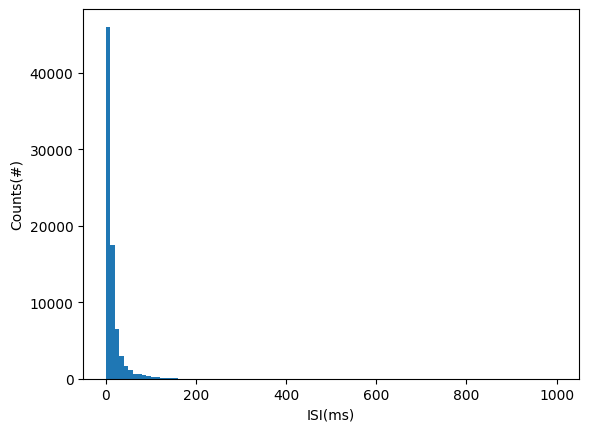

In [ ]:
def batch_map_via_queries(data, cell, FD, settings_dict, session_position, df_summary, root_directory_paths, tetrode_directory_paths):

    columns = ['Session', 'Tetrode', 'Cell ID']
    tasks = settings_dict['tasks']
    plotTasks = settings_dict['plotTasks']
    csv_header = settings_dict['header']
    arena_size = settings_dict['arena_size']

    # Kernel size
    kernlen = int(settings_dict['smoothing_factor']*8)
    # Standard deviation size
    std = int(0.2*kernlen)

    # Set flag if no arguments were provided for later
    all_cells = False
    if (settings_dict['start_cell'] == settings_dict['end_cell'] == None):
        all_cells = True

    # Initialize empty dataframe with columns
    headers = [k for k, v in csv_header.items() if v]
    if 'border_score' in headers:
        idx = headers.index('border_score') 
        headers.remove('border_score')
        headers.insert(idx, 'border_score_top')
        headers.insert(idx+1, 'border_score_bottom')
        headers.insert(idx+2, 'border_score_left')
        headers.insert(idx+3, 'border_score_right')

    if len(df_summary) == 0:
        df_summary = pd.DataFrame(columns=columns+headers)

    session_query = data
    session_name = next(iter(session_query))
    waveform_array = session_query[session_name]['tet_waveforms']
    spike_times = session_query[session_name]['spike_times'].to_numpy().squeeze()
    signature = session_position.attrs["session_data_ref"]["data_name"]
    animal_id = waveform_array.attrs["animal_data_ref"]['data_name']
    tet_id = waveform_array.attrs["probe_data_ref"]['data_name']
    # if tet_id != '1':
    print('tetrode id:', tet_id)
    df_summary.loc[len(df_summary)] = {
        'Session': signature,
        'Tetrode': tet_id,
        'Cell ID': cell
    }
    if all_cells == True or ((all_cells==False) & (cell >= settings_dict['start_cell'] & cell <= settings_dict['end_cell'])):
        print('animal: ' + str(animal_id) + ', session: ' + str(settings['per_session_tracker'] + 1) + ', cell_cluster_label: ' + str(cell))
        # spatial_spike_train = SpatialSpikeTrain2D_signalstore({'cell': cell,
        #                                                        'position': session_position,
        #                                                        'spike_times': spike_times,
        #                                                        'speed_bounds': (settings_dict['speed_lowerbound'], settings_dict['speed_upperbound'])},
        #                                                        arena_size=arena_size,
        #                                                        smoothing_factor=settings_dict['smoothing_factor'],
        #                                                        isCylinder=settings_dict.get('isCylinder', False))
        # pos_x, pos_y, pos_t, arena_size = spatial_spike_train.x, spatial_spike_train.y, spatial_spike_train.t, spatial_spike_train.arena_size
        pos_x, pos_y, pos_t, arena_size = session_position.isel(xyt=0).values.squeeze(), session_position.isel(xyt=1).values.squeeze(), session_position.isel(xyt=2).values.squeeze(), arena_size
        v = speed2D(pos_x, pos_y, pos_t)
        # v = speed2D(spatial_spike_train.x, spatial_spike_train.y, spatial_spike_train.t)
        # rate_obj = spatial_spike_train.get_map('rate')
        rate_map, rate_map_raw, occ_map, occ_map_raw, spike_map, spike_map_raw = get_maps(pos_x, pos_y, pos_t,
                                              spike_times, arena_size,
                                              settings_dict['smoothing_factor'],
                                              (settings_dict['speed_lowerbound'], settings_dict['speed_upperbound']),
                                              settings_dict['interp_size'],
                                              useMinMaxPos=False)
        cell_stats = {}
        # occ_obj = spatial_spike_train.get_map('occupancy')
        # occ_map, _, _ = occ_obj.get_occupancy_map()
        # spike_obj = spatial_spike_train.get_map('spike')
        # spike_map, _ = spike_obj.get_spike_map()
        spikex, spikey, spiket = pos_x, pos_y, spike_times
        if tasks['spike_analysis']:
            idx = np.where(data_concat_lbl == cell)[0]
            ClusterSpikes = idx
            L, ratio_L, df = L_ratio(FD, ClusterSpikes)
            iso_dist = isolation_distance(FD, ClusterSpikes)
            bursting, avg_spikes_per_burst = find_burst(spike_times)
            ISI_dict = histogram_ISI(spike_times)
            spike_count = len(spike_times)

        if tasks['spike_width']:
            n_spikes = len(spike_times)
            waveforms = waveform_array.values.squeeze()
            wf_avg = np.array(waveforms).mean(axis=1)
            max_vals = list(map(lambda x: max(x), [val for val in wf_avg]))
            principal_channel_index = np.argmax(max_vals)
            principal_waveform = wf_avg[principal_channel_index]
            peak_index = np.argmax(principal_waveform)
            trough_list = list(filter(lambda x: x > peak_index, troughs(principal_waveform)))
            sample_rate = float(waveform_array.attrs.get('sampling_rate', 48000))
            if len(trough_list) > 0:
                trough_index = trough_list[0]
                spike_width = (trough_index - peak_index) / sample_rate
            else:
                trough_index = len(principal_waveform) - 1
                spike_width = int((trough_index - peak_index)/2) / sample_rate
            if spike_width < 0:
                warnings.warn(f'Negative spike width for unit {cell} in session {signature}.\n\nThe mean waveform is:\n{principal_waveform}\n\nThe peak index is {peak_index} and the trough index is {trough_index}. The spike width is {spike_width}.\n\nThe sample_rate is {sample_rate}.')
            duration = float(waveform_array.attrs.get('duration', 601.0))  # Default to 601 second if not specified
            firing_rate = n_spikes/duration
            cell_stats['firing_rate'] = firing_rate
            cell_stats['spike_width'] = spike_width

        if settings_dict.get('isCylinder', False): ## records data
            tasks['disk_arena'] = True
            rate_map = flat_disk_mask(rate_map)
            occ_map = flat_disk_mask(occ_map)
            rate_map_raw = flat_disk_mask(rate_map_raw)
        else:
            tasks['disk_arena'] = False

        autocorr_map = autocorrelation(rate_map, use_map_directly=True, smoothing_factor=settings['smoothing_factor'], arena_size=arena_size)
        ratemap_stats_dict  = rate_map_stats(None, ratemap=rate_map, occmap=occ_map, override=True)

        cell_stats['rate_map_smooth'] = rate_map
        cell_stats['occupancy_map'] = occ_map
        cell_stats['rate_map_raw'] = rate_map_raw
        cell_stats['autocorrelation_map'] = autocorr_map
        # cell_stats['spatial_spike_train'] = spatial_spike_train

        if tasks['binary_map']:
            binmap = binary_map(rate_map, use_map_directly=True, smoothing_factor=settings['smoothing_factor'])
            cell_stats['binary_map'] = binmap

        if tasks['autocorrelation_map']:
            cell_stats['autocorr_map'] = autocorr_map

        if tasks['sparsity']:
            cell_stats['sparsity'] = ratemap_stats_dict['sparsity']

        if tasks['selectivity']:
            cell_stats['selectivity'] = ratemap_stats_dict['selectivity']

        if tasks['information']:
            cell_stats['spatial_information_content'] = ratemap_stats_dict['spatial_information_content']

        if tasks['coherence']:
            coherence = rate_map_coherence(rate_map_raw, smoothing_factor=settings['smoothing_factor'])
            cell_stats['coherence'] = coherence

        if tasks['speed_score']:
            s_score = speed_score(spike_times, pos_x, pos_y, pos_t)
            cell_stats['speed_score'] = s_score
        
        if tasks['hd_score'] or tasks['tuning_curve']:
            tuned_data, spike_angles, angular_occupancy, bin_array = spatial_tuning_curve(spike_times, pos_x, pos_y,
                                                                                          pos_t, smoothing_factor=settings_dict['smoothing_factor'])
            cell_stats['tuned_data'] = tuned_data
            cell_stats['tuned_data_angles'] = spike_angles
            cell_stats['angular_occupancy'] = angular_occupancy
            cell_stats['angular_occupancy_bins'] = bin_array

        if tasks['hd_score']:
            hd_hist = hd_score(spike_angles)
            cell_stats['hd_hist'] = hd_hist

        if tasks['grid_score']:
            true_grid_score = grid_score(rate_map, autocorr_map, smoothing_factor=settings_dict['smoothing_factor'])
            cell_stats['grid_score'] = true_grid_score

        if tasks['border_score'] and not tasks['disk_arena']:
            b_score = border_score(rate_map, smoothing_factor=settings_dict['smoothing_factor'])
            cell_stats['b_score_top'] = b_score[0]
            cell_stats['b_score_bottom'] = b_score[1]
            cell_stats['b_score_left'] = b_score[2]
            cell_stats['b_score_right'] = b_score[3]
        elif tasks['border_score'] and tasks['disk_arena']:
            print('Cannot compute border score on disk arena')

        if tasks['field_sizes']:
            image, n_labels, labels, centroids, field_sizes = map_blobs(rate_map, smoothing_factor=settings_dict['smoothing_factor'])
            cell_stats['field_size_data'] = {'image': image, 'n_labels': n_labels, 'labels': labels, 'centroids': centroids, 'field_sizes': field_sizes}

        if settings_dict['saveData'] == True:

            if plotTasks['rate_map']:
                colored_ratemap = Image.fromarray(np.uint8(cm.jet(rate_map)*255))
                colored_ratemap.save(tetrode_directory_paths[directory] + '/ratemap_cell_' + str(cell) + '.png')
            
            if plotTasks['occupancy_map']:
                colored_occupancy_map = Image.fromarray(np.uint8(cm.jet(occ_map)*255))
                colored_occupancy_map.save(root_directory_paths['Occupancy_Map'] + '/pospdf_cell' + str(cell) + '.png')

            if plotTasks['binary_map']:
                im = Image.fromarray(np.uint8(binmap*255))
                im.save(tetrode_directory_paths[directory] + '/Binary_Map_Cell_' + str(cell) + '.png')

            excel_cell_index = len(df_summary) -1

            # Sparsity, Selectivity and Shannon
            if tasks['sparsity']:
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, {'sparsity': ratemap_stats_dict['sparsity']})

            if tasks['selectivity']:
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, {'selectivity': ratemap_stats_dict['selectivity']})

            if tasks['information']:
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, {'selectivity': ratemap_stats_dict['spatial_information_content']})

            if tasks['spike_width']:
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, {'spike_width': spike_width})
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, {'firing_rate': firing_rate})

            if tasks['spike_analysis']:
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, {'bursting': bursting})
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, {'Avg. Spikes/Burst': avg_spikes_per_burst})
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, {'L_ratio': ratio_L})
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, {'iso_dist': iso_dist})
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, {'iso_dist': iso_dist})
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, {
                                                                'ISI_min': ISI_dict['min'],
                                                                'ISI_max': ISI_dict['max'],
                                                                'ISI_median': ISI_dict['median'],
                                                                'ISI_mean': ISI_dict['mean'],
                                                                'ISI_std': ISI_dict['std'],
                                                                'ISI_cv': ISI_dict['cv'],
                                                                'spike_count': spike_count
                                                               })
                
            if plotTasks['autocorr_map']:
                im = Image.fromarray(np.uint8(cm.jet(autocorr_map)*255))
                im.save(tetrode_directory_paths[directory] + '/autocorr_cell_' + str(cell) + '.png')
            row_dict = {}
            if tasks['border_score'] and not tasks['disk_arena']:
                row_dict.update({
                    'border_score_top': b_score[0],
                    'border_score_bottom': b_score[1],
                    'border_score_left': b_score[2],
                    'border_score_right': b_score[3]
                })

            if tasks['coherence']:
                row_dict['coherence'] = coherence

            if tasks['speed_score']:
                row_dict['speed_score'] = s_score[0]['2016']

            if tasks['hd_score']:
                row_dict['hd_score'] = get_hd_score_for_cluster(hd_hist)

            if tasks['grid_score']:
                row_dict['grid_score'] = true_grid_score
                shuffle_check = True

            # Append to df_summary
            if row_dict:
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, row_dict)

            if tasks['field_sizes']:
                # Prepare the dictionary to insert
                field_sizes = cell_stats['field_size_data']['field_sizes']
                field_data_dict = {}

                for j, field_size in enumerate(field_sizes):
                    field_col_name = f'Field_{j + 1}'
                    field_data_dict[field_col_name] = field_size

                # Append this row to df_summary
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, field_data_dict)

            # Firing rate vs. time, for a window of 400 millieconds
            if plotTasks['Firing_Rate_vs_Time_Plots']:
                firing_rate, firing_time = firing_rate_vs_time(spike_times.values.squeeze(), pos_t, 400)
                fig = plt.figure()
                figure = plt.gcf()
                figure.set_size_inches(4, 4)
                plt.title('Firing Rate vs. Time')
                plt.xlabel('Time (seconds)')
                plt.ylabel('Firing Rate (Hertz)')
                plt.plot(pos_t, firing_rate, linewidth=0.25)
                plt.savefig(tetrode_directory_paths[directory] + '/FRvT_cell_' + str(cell) + '.png', dpi=300, bbox_inches = 'tight')
                plt.close(fig)

            # Firing rate vs. speed
            if plotTasks['Firing_Rate_vs_Speed_Plots']:
                fig = plt.figure()
                figure = plt.gcf()
                figure.set_size_inches(4, 4)
                plt.title('Firing Rate vs. Speed')
                plt.xlabel('Speed (cm/s)')
                plt.ylabel('Firing Rate (Hertz)')
                plt.scatter(v, firing_rate, s = 0.5)
                plt.savefig(tetrode_directory_paths[directory] + '/FRvS_cell_' + str(cell) + '.png', dpi=300, bbox_inches = 'tight')
                plt.close(fig)

            # Plotting tuning curves (polar plots for directional firing) per cell
            if plotTasks['Tuning_Curve_Plots']:
                tuned_data = cell_stats['tuned_data'] 
                spike_angles = cell_stats['tuned_data_angles']
                angular_occupancy = cell_stats['angular_occupancy']
                bin_array = cell_stats['angular_occupancy_bins']
                last_and_first_averaged = (tuned_data[0]+tuned_data[-1]) / 2
                tuned_data[0] = last_and_first_averaged
                tuned_data[-1] = last_and_first_averaged

                fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
                ax.plot(bin_array, tuned_data, linewidth=6)
                ax.set_xticks(np.arange(0,2.0*np.pi,np.pi/2.0))
                ax.set_yticks(np.linspace(  0, max(tuned_data), 2)[-1]  )
                plt.title("Polar plot")
                plt.box(on=None)
                plt.savefig(tetrode_directory_paths[directory] + '/tuning_curve_cell_' + str(cell) + '.png', dpi=300, bbox_inches = 'tight')
                plt.close(fig)

            # Spikes over position map
            if plotTasks['Spikes_Over_Position_Map']:
                fig = plt.figure()
                figure = plt.gcf()
                figure.set_size_inches(4, 4)
                plt.plot(pos_x,pos_y, linewidth=0.2)
                plt.scatter(spikex,spikey, c='r', s=5, zorder=3)
                plt.title("Spikes over position")
                plt.xlabel("x coordinates")
                plt.ylabel("y coordinates")
                plt.gca().set_aspect('equal', adjustable='box')
                plt.savefig(tetrode_directory_paths[directory] + '/spikes_over_position_cell_' + str(cell) + '.png', dpi=300, bbox_inches = 'tight')
                plt.close(fig)

            if plotTasks['Waveforms_Across_Channels']:
                fig = WaveformTemplateFig()

                for i in range(4):
                    ch = waveforms[:,i,:]
                    idx = np.random.choice(len(ch), size=200)
                    waves = ch[idx, :]
                    avg_wave = np.mean(ch, axis=0)

                    fig.waveform_channel_plot(waves, avg_wave, str(i+1), fig.ax[str(i+1)])

                cell_id = cell
                title = str(animal_id) + '_tetrode_' + str(tet_id) + '_' + str(signature) + '_unit_' + str(cell_id)

                fig.f.suptitle(title, ha='center', fontweight='bold', fontsize='large')
                plt.savefig(tetrode_directory_paths[directory] + '/waveforms_across_channels' + str(cell) + '.png', dpi=300, bbox_inches = 'tight')
                plt.close(fig.f)

            print("Cell " + str(cell_id) + " is complete")

    return df_summary, animal_id, tet_id, session_name, sample


            
                





    
save_dir = pathlib.Path.cwd().parent / r"data" / r"output"
root_path = os.path.join(save_dir, 'All_Neurofunc_Sessions_iter_')
run_number = 1
while os.path.isdir(root_path+str(run_number)):
    run_number+=1

root_path += str(run_number)
os.mkdir(root_path)

file_name = os.path.join(root_path, "neurofunc_parameters.txt")
with open(file_name, 'w') as f:
    for ky in settings:
        f.write(str(ky) + ' is: ')
        f.write(str(settings[ky]) + '\n')
    f.close()

all_cells = False
if (settings['start_cell'] == settings['end_cell'] == None):
    all_cells = True
settings['all_cells'] = all_cells
settings['per_animal_tracker'] = 0
settings['per_animal_tetrode_tracker'] = 0
settings['per_session_tracker'] = 0

## for all queries
with unit_of_work as uow:
    # query = {
    #     "schema_ref": "spike_labels"
    # }
    sorted_by = [("session_start", -1)]
    sessions = uow.data.find(main_query)

df_summary = pd.DataFrame()
visited_animal = []
visited_tetrode = []
visited_session = []

with unit_of_work as uow: 
    visited = []
    for i in range(len(sessions)):
        print('*'*20)
        sample = sessions[i]['data_name']
        # print('sample id', sample)
        print('Processing session', i+1, 'of', len(sessions), "sample id:", sample)
        if sample in visited:
            continue

        visited.append(sample)

        session_labels = uow.data.get('spike_labels', sample)
        session_name = session_labels.attrs.get('session_data_ref')["data_name"]
        animal_id = session_labels.attrs["animal_data_ref"]['data_name']
        session_position = uow.data.get('animal_position',  session_name)
        tet_id = session_labels.attrs.get('probe_data_ref')["data_name"]
        all_cells = list(set(session_labels[:, 0].values))
        print('all_cells', all_cells)

        query = {
        "data_name": sample
        }
        if settings['saveData'] == True:
            save_path = os.path.join(root_path, 'animal_' + animal_id, 'neurofunc_session_' + session_name) 
            if not os.path.isdir(save_path):
                os.makedirs(save_path, exist_ok=True)
                root_directory_paths = dict()
                root_directory_paths['Occupancy_Map'] = os.path.join(save_path, 'Occupancy_Map')
                # Creating occupancy map directory
                if not os.path.isdir(root_directory_paths['Occupancy_Map']):
                    os.mkdir(root_directory_paths['Occupancy_Map'])
                # Building save directories for tetrodes
            directory = 'Tetrode_' + tet_id
            tetrode_directory_paths = dict()
            # for directory in tetrode_directories:
            path = os.path.join(save_path, directory)
            if not os.path.isdir(path):
                os.mkdir(path)
            tetrode_directory_paths[directory] = path
        tasks = settings['tasks']
        if tasks['spike_analysis']:
            for i, cell in enumerate(all_cells):
                data = view_query_factory(uow, 
                                        query,
                                        cell_id=cell,
                                        exclude=['animal_position'])
                ch = np.squeeze(data[sample].tet_waveforms,axis=-1)
                ch_lbl = np.squeeze(data[sample].spike_labels, axis=-1)
                if i == 0:
                    data_concat = ch
                    data_concat_lbl = ch_lbl
                else:
                    data_concat = np.vstack((data_concat, ch))
                    data_concat_lbl = np.hstack((data_concat_lbl, ch_lbl))
            data_concat = data_concat.reshape((4, -1, ch.shape[2]))
            FD = create_features(data_concat)
        else:
            FD = None
        
        for cell in all_cells:
            print(f"processing cell, {str(cell)} for sample {sample}")
            data = view_query_factory(uow, 
                                      query,
                                      cell_id=cell,
                                      exclude=['animal_position'])
            arena_name = settings.get('arena_name', "Arena1_MEC")
            arena_record_query = {
                "schema_ref": "arena",
                "data_name": arena_name
            }
            arena_record = uow.data.get(arena_record_query['schema_ref'], arena_record_query['data_name'])
            arena_size, isCylinder = extract_arena_size_from_shape(arena_record)
            settings['arena_size'] = arena_size
            settings['isCylinder'] = isCylinder
            df_summary, animal_id, tet_id, session_name, sample = batch_map_via_queries(data, cell, FD, settings, session_position, df_summary, root_directory_paths, tetrode_directory_paths)
        if animal_id not in visited_animal:
            visited_animal.append(animal_id)
            settings['per_animal_tracker'] += 1
            df_save_path = os.path.join(root_path, f"animal_{animal_id}")
            os.makedirs(df_save_path, exist_ok=True)
            if animal_id != visited_animal[-1]: ## If new animal, reset df_summary
                print(f"Saving summary for animal {animal_id} at {df_save_path}")
                df_summary = pd.DataFrame()
        if len(df_summary) > 0:
            df_summary.to_csv(os.path.join(df_save_path, f"neurofunc_animal_{animal_id}_summary.csv"), index=False)